In [1]:

from obspy import Inventory, UTCDateTime, read
from obspy.clients.fdsn import Client
date_range = ["2025-01-22", "2025-01-22"]
dpath = '/Users/oxide/Documents/research/orenstein/code/P288FinalProject/alex/data/'

Instruments of Poas:
- VPCC: seismic
- VPPC: seismic, GNSS (seems to be missing), CO2
- VPRS: seismic and magnetometry 
- VPMI: GNSS, weather (no data available on API)
- VPNC: (no data available)

In [2]:
# functions

def get_inventory(station, dates, channel='*', level='channel', network='OV'):
    '''
    get inventory for a given station
    '''

    client = Client("IRIS")

    starttime = UTCDateTime(f'{dates[0]}')
    endtime = starttime = UTCDateTime(f'{dates[1]}')+86400
    inventory = client.get_stations(
        network=network,
        station=station,
        starttime=starttime,
        endtime=endtime,
        channel=channel,
        level=level
    )
    
    return inventory

def get_stream(station, dates, channel, network='OV', kwargs={}):

    client = Client("IRIS")

    starttime = UTCDateTime(f'{dates[0]}')
    endtime = starttime = UTCDateTime(f'{dates[1]}')+86400

    # Get a day of waveform data from the data center
    stream = client.get_waveforms(
        network=network,
        station=station,
        location="*",
        channel=channel,
        starttime=starttime,
        endtime=endtime,
        **kwargs
    )
    stream.merge(method=-1)

    return stream

def check_response(station, dates):
    '''
    Given an inventory, check whether there is any corresponding response to any of the channels
    '''

    inventory = get_inventory(station, dates)

    # Check each channel
    for network in inventory:
        for station in network:
            print(f"\nStation: {station.code}")
            for channel in station:
                print(f"\n  Channel: {channel.code} ({channel.location_code})")
                
                if channel.response:
                    print(f"    ✓ Has response data")
                    sens = channel.response.instrument_sensitivity
                    print(f"    Sensitivity: {sens.value} {sens.input_units}/{sens.output_units}")
                    print(f"    Frequency: {sens.frequency} Hz")
                    
                    # Check if it's a full response or just sensitivity
                    if len(channel.response.response_stages) > 1:
                        print(f"    Full response ({len(channel.response.response_stages)} stages)")
                    else:
                        print(f"    Simple response (sensitivity only)")
                else:
                    print(f"    ✗ No response data available")

def get_seismic_data(station, dates, network='OV', datapath=dpath):
    '''
    Get seismic data

    channel: 'HH*' for seismic, 'LF*' for magnetic
    '''

    client = Client("IRIS")

    # Get the instrument response inventory for a single station - don't think I need it in the end
    inventory = Inventory()
    inventory += get_inventory(station, dates)
    inventory.write(f'{datapath}{station}_mag_response.xml', format="STATIONXML")

    # Get a day of waveform data from the data center
    stream = get_stream(station, dates, channel='HH*', kwargs={'attach_response':True})

    # remove the response
    stream.remove_response(output='VEL', pre_filt=(0.01, 0.02, 20, 40), water_level=60)

    # Write each component to a separate miniSEED file
    # E,N,Z refers to three orientations of the seismometers
    for component in "ENZ":
        component_stream = stream.select(component=component)
        component_stream.write(f'{datapath}{network}.{station}_HH{component}.m', format="MSEED")

    return stream

def get_magnetic_data(station, dates, network='OV', datapath=dpath):
    '''
    Get seismic data

    channel: 'HH*' for seismic, 'LF*' for magnetic
    '''

    client = Client("IRIS")

    # Get a day of waveform data from the data center
    stream = get_stream(station, dates, channel='LF*', kwargs={'attach_response':True})

    stream.remove_sensitivity()

    # Write each component to a separate miniSEED file
    # E,N,Z refers to three orientations of the seismometers
    for component in "ENZ":
        component_stream = stream.select(component=component)
        component_stream.write(f'{datapath}{network}.{station}_LF{component}.m', format="MSEED")

    return stream

### Seismic

In [25]:
# seismic
seis = []
for stat in ['VPCC', 'VPPC', 'VPRS']:
    try:
        seis.append(get_seismic_data(stat, date_range))
    except Exception as e:
        print(f'error in processing {stat}:')
        print(e)

/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/obspy/io/mseed/core.py:773: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


error in processing VPPC:
No data available for request.
HTTP Status code: 204
Detailed response of server:




/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/obspy/io/mseed/core.py:773: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


### Magnetic

In [4]:
mag_VPRS = get_magnetic_data('VPRS', date_range)

/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/obspy/io/mseed/core.py:773: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


In [10]:
mag_VPRS[0]

OV.VPRS..LFE | 2025-01-23T00:00:00.000000Z - 2025-01-23T00:00:00.000000Z | 1.0 Hz, 1 samples

/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/obspy/imaging/waveform.py:412: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xmin, xmax)


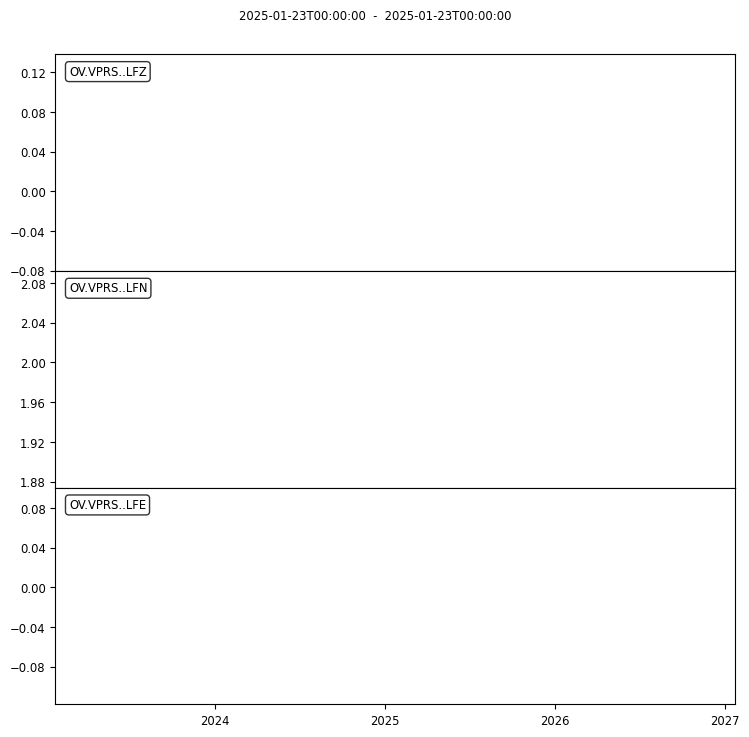

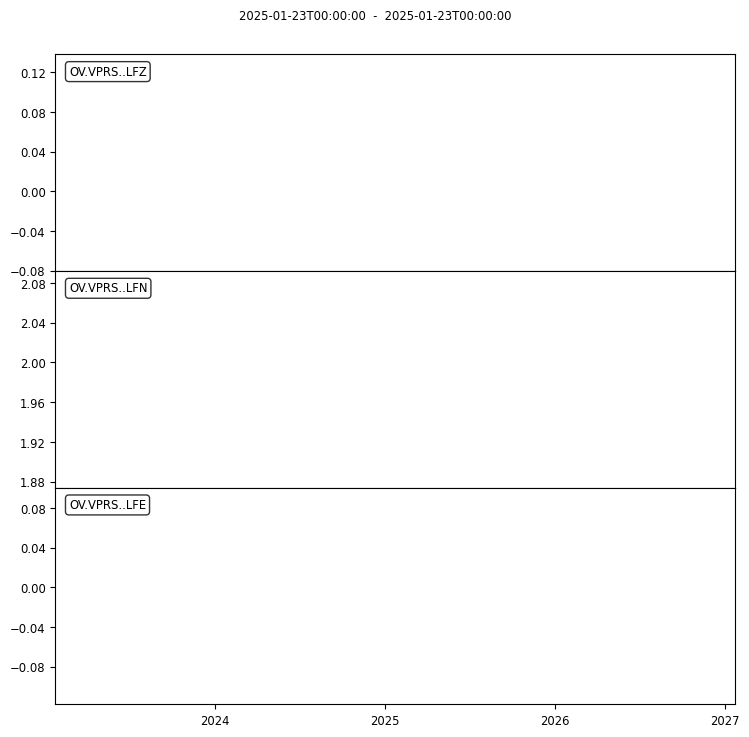

In [5]:
mag_VPRS.plot()